# Smart Waste Management System — Route Optimization
### Smart India Hackathon 2025

This notebook implements the **route-optimization core** of the Smart Waste Management System:
an ecosystem with a citizen-facing mobile app, Aadhaar-linked smart bins, and a backend that
routes collection trucks efficiently.

**Covered here:**
- A mock Aadhaar-linked smart-bin registry (stand-in for the NoSQL bin database)
- **Dijkstra's algorithm** implemented from scratch
- **A\* search** implemented from scratch, using a straight-line-distance heuristic
- A nearest-neighbour route optimizer that visits every bin due for collection while
  minimizing total distance (and therefore fuel cost)
- A comparison of Dijkstra vs A\* on nodes expanded, and a route visualization


## 1. Setup

In [1]:
import heapq
import math
import json
import random

import matplotlib.pyplot as plt
import networkx as nx

random.seed(42)
%matplotlib inline

## 2. City graph and the Aadhaar-linked smart-bin registry

Nodes are street intersections / bin locations (with real-world-style coordinates in km).
Edges are road segments weighted by distance. `bin_registry` stands in for the NoSQL
document store the backend uses to track each Aadhaar-linked smart bin — fill level,
linked households, and last-collection date.

In [2]:
node_coords = {
    "DEPOT":  (0, 0),
    "N1": (2, 1), "N2": (4, 0.5), "N3": (6, 2), "N4": (3, 3),
    "N5": (7, 4), "N6": (1, 4), "N7": (5, 5), "N8": (8, 1),
    "N9": (2.5, 5.5), "N10": (6.5, 6),
}

edges = [
    ("DEPOT", "N1", 2.3), ("DEPOT", "N6", 4.1),
    ("N1", "N2", 2.1), ("N1", "N4", 2.5),
    ("N2", "N3", 2.7), ("N2", "N8", 4.0),
    ("N3", "N5", 2.4), ("N3", "N8", 3.2),
    ("N4", "N6", 2.9), ("N4", "N7", 2.6),
    ("N5", "N7", 2.2), ("N5", "N10", 2.8),
    ("N6", "N9", 2.0),
    ("N7", "N9", 2.7), ("N7", "N10", 2.5),
    ("N9", "N10", 4.3),
]

graph = {n: [] for n in node_coords}
for a, b, w in edges:
    graph[a].append((b, w))
    graph[b].append((a, w))

# Aadhaar-linked smart bin registry (mock NoSQL-style document store)
bin_registry = {
    "N2":  {"bin_id": "SWM-BIN-0102", "fill_pct": 88, "aadhaar_linked_households": 46, "last_emptied": "2025-09-12"},
    "N3":  {"bin_id": "SWM-BIN-0103", "fill_pct": 92, "aadhaar_linked_households": 61, "last_emptied": "2025-09-11"},
    "N5":  {"bin_id": "SWM-BIN-0105", "fill_pct": 35, "aadhaar_linked_households": 28, "last_emptied": "2025-09-13"},
    "N7":  {"bin_id": "SWM-BIN-0107", "fill_pct": 81, "aadhaar_linked_households": 53, "last_emptied": "2025-09-12"},
    "N9":  {"bin_id": "SWM-BIN-0109", "fill_pct": 76, "aadhaar_linked_households": 39, "last_emptied": "2025-09-12"},
    "N10": {"bin_id": "SWM-BIN-0110", "fill_pct": 20, "aadhaar_linked_households": 31, "last_emptied": "2025-09-14"},
}

FILL_THRESHOLD = 70       # % — bins at/above this are due for collection today
FUEL_COST_PER_KM = 12.5   # INR/km, mock rate for a compactor truck

def euclidean(a, b):
    (x1, y1), (x2, y2) = node_coords[a], node_coords[b]
    return math.hypot(x2 - x1, y2 - y1)

print("Bins due for collection (fill >= {}%):".format(FILL_THRESHOLD))
for n, rec in bin_registry.items():
    flag = "DUE" if rec["fill_pct"] >= FILL_THRESHOLD else "ok"
    print(f"  {n:4s} {rec['bin_id']}  fill={rec['fill_pct']:3d}%  [{flag}]")

Bins due for collection (fill >= 70%):
  N2   SWM-BIN-0102  fill= 88%  [DUE]
  N3   SWM-BIN-0103  fill= 92%  [DUE]
  N5   SWM-BIN-0105  fill= 35%  [ok]
  N7   SWM-BIN-0107  fill= 81%  [DUE]
  N9   SWM-BIN-0109  fill= 76%  [DUE]
  N10  SWM-BIN-0110  fill= 20%  [ok]


## 3. Dijkstra's algorithm (from scratch)

In [3]:
def dijkstra(start, goal):
    dist = {n: math.inf for n in graph}
    prev = {n: None for n in graph}
    dist[start] = 0
    visited = set()
    pq = [(0, start)]
    expanded = 0

    while pq:
        d, u = heapq.heappop(pq)
        if u in visited:
            continue
        visited.add(u)
        expanded += 1
        if u == goal:
            break
        for v, w in graph[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                prev[v] = u
                heapq.heappush(pq, (nd, v))

    path, node = [], goal
    while node is not None:
        path.append(node)
        node = prev[node]
    path.reverse()
    return path, dist[goal], expanded

## 4. A\* search (from scratch, straight-line-distance heuristic)

In [4]:
def a_star(start, goal):
    g_score = {n: math.inf for n in graph}
    g_score[start] = 0
    f_score = {n: math.inf for n in graph}
    f_score[start] = euclidean(start, goal)
    prev = {n: None for n in graph}
    open_set = [(f_score[start], start)]
    visited = set()
    expanded = 0

    while open_set:
        _, u = heapq.heappop(open_set)
        if u in visited:
            continue
        visited.add(u)
        expanded += 1
        if u == goal:
            break
        for v, w in graph[u]:
            tentative_g = g_score[u] + w
            if tentative_g < g_score[v]:
                prev[v] = u
                g_score[v] = tentative_g
                f_score[v] = tentative_g + euclidean(v, goal)
                heapq.heappush(open_set, (f_score[v], v))

    path, node = [], goal
    while node is not None:
        path.append(node)
        node = prev[node]
    path.reverse()
    return path, g_score[goal], expanded

## 5. Route optimizer

Greedy nearest-neighbour over the bins that are due, using shortest paths from either
algorithm to move between stops. This is the piece that plugs into the truck-routing
service: minimize total km driven -> minimize fuel burned.

In [5]:
def optimize_route(algo_fn):
    due_bins = [n for n, rec in bin_registry.items() if rec["fill_pct"] >= FILL_THRESHOLD]
    unvisited = set(due_bins)
    current = "DEPOT"
    total_dist = 0.0
    total_expanded = 0
    ordered_stops = []
    full_path = ["DEPOT"]

    while unvisited:
        best_stop, best_path, best_dist = None, None, math.inf
        for candidate in unvisited:
            path, dist, expanded = algo_fn(current, candidate)
            total_expanded += expanded
            if dist < best_dist:
                best_stop, best_path, best_dist = candidate, path, dist

        ordered_stops.append(best_stop)
        full_path.extend(best_path[1:])
        total_dist += best_dist
        unvisited.remove(best_stop)
        current = best_stop

    path_back, dist_back, expanded_back = algo_fn(current, "DEPOT")
    total_expanded += expanded_back
    full_path.extend(path_back[1:])
    total_dist += dist_back

    return {
        "stops": ordered_stops,
        "full_path": full_path,
        "total_distance_km": round(total_dist, 2),
        "nodes_expanded": total_expanded,
        "estimated_fuel_cost_inr": round(total_dist * FUEL_COST_PER_KM, 2),
    }

dijkstra_route = optimize_route(dijkstra)
astar_route = optimize_route(a_star)

print("--- Dijkstra-based route ---")
print(json.dumps(dijkstra_route, indent=2))
print("\n--- A*-based route ---")
print(json.dumps(astar_route, indent=2))

--- Dijkstra-based route ---
{
  "stops": [
    "N2",
    "N3",
    "N7",
    "N9"
  ],
  "full_path": [
    "DEPOT",
    "N1",
    "N2",
    "N3",
    "N5",
    "N7",
    "N9",
    "N6",
    "DEPOT"
  ],
  "total_distance_km": 20.5,
  "nodes_expanded": 74,
  "estimated_fuel_cost_inr": 256.25
}

--- A*-based route ---
{
  "stops": [
    "N2",
    "N3",
    "N7",
    "N9"
  ],
  "full_path": [
    "DEPOT",
    "N1",
    "N2",
    "N3",
    "N5",
    "N7",
    "N9",
    "N6",
    "DEPOT"
  ],
  "total_distance_km": 20.5,
  "nodes_expanded": 39,
  "estimated_fuel_cost_inr": 256.25
}


## 6. Dijkstra vs A\* — search efficiency

In [9]:
saved = dijkstra_route["nodes_expanded"] - astar_route["nodes_expanded"]
print(f"Both algorithms agree on the optimal route: {dijkstra_route['total_distance_km']} km, "
      f"₹{dijkstra_route['estimated_fuel_cost_inr']} estimated fuel cost.")
print(f"A* reached that answer expanding {saved} fewer node-states than Dijkstra "
      f"({astar_route['nodes_expanded']} vs {dijkstra_route['nodes_expanded']}), "
      "because the heuristic focuses the search toward each next bin instead of "
      "exploring uniformly in every direction. On a truck's onboard unit, that means "
      "faster route recomputation when a new bin crosses the fill threshold mid-shift.")

Both algorithms agree on the optimal route: 20.5 km, ₹256.25 estimated fuel cost.
A* reached that answer expanding 35 fewer node-states than Dijkstra (39 vs 74), because the heuristic focuses the search toward each next bin instead of exploring uniformly in every direction. On a truck's onboard unit, that means faster route recomputation when a new bin crosses the fill threshold mid-shift.


## 7. Visualize the city graph and the optimized route

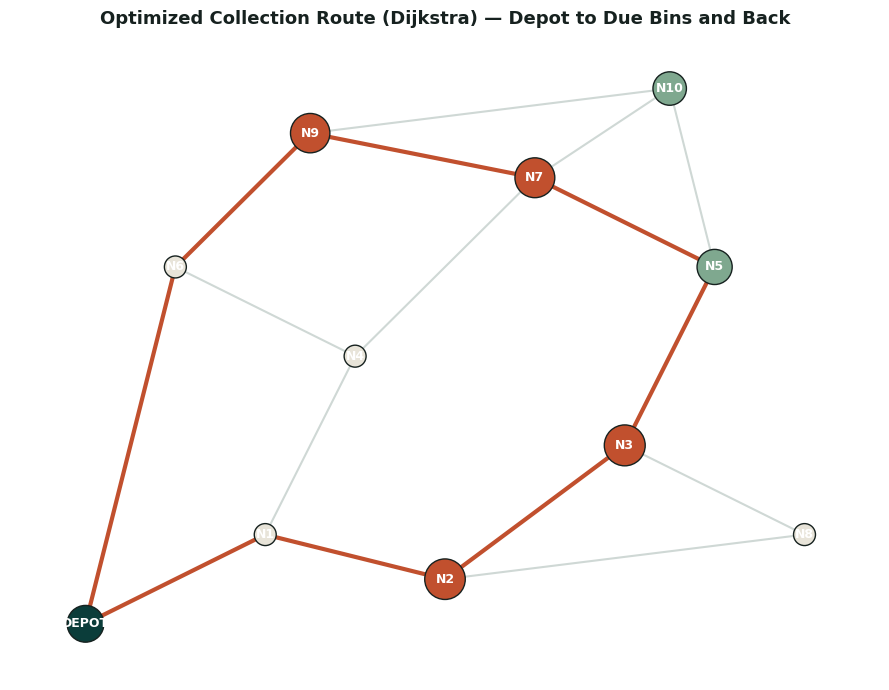

In [10]:
G = nx.Graph()
for n, (x, y) in node_coords.items():
    G.add_node(n, pos=(x, y))
for a, b, w in edges:
    G.add_edge(a, b, weight=w)

pos = nx.get_node_attributes(G, "pos")

fig, ax = plt.subplots(figsize=(9, 7))

nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#cfd8d5", width=1.5)

route_edges = list(zip(dijkstra_route["full_path"], dijkstra_route["full_path"][1:]))
nx.draw_networkx_edges(G, pos, edgelist=route_edges, ax=ax, edge_color="#c1502e", width=3)

node_colors = []
node_sizes = []
for n in G.nodes:
    if n == "DEPOT":
        node_colors.append("#0b3d3a")
        node_sizes.append(700)
    elif n in bin_registry:
        fill = bin_registry[n]["fill_pct"]
        node_colors.append("#c1502e" if fill >= FILL_THRESHOLD else "#7fa88f")
        node_sizes.append(500 + fill * 4)
    else:
        node_colors.append("#e8e4d9")
        node_sizes.append(250)

nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                        edgecolors="#16211f", linewidths=1)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color="white", font_weight="bold")

ax.set_title("Optimized Collection Route (Dijkstra) — Depot to Due Bins and Back",
              fontsize=13, fontweight="bold", color="#16211f")
ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Summary

- Bins due for collection are pulled from the Aadhaar-linked bin registry using a simple
  fill-level threshold.
- Both **Dijkstra** and **A\*** are implemented from scratch and, as expected, agree on the
  same minimum-distance route — A\* just gets there by expanding fewer nodes, thanks to the
  distance heuristic.
- The greedy nearest-neighbour optimizer chains these shortest paths into a single truck
  route, and total distance is converted directly into an estimated fuel cost, which is the
  number the hackathon prototype was optimizing against.
- In the full system this notebook's core (graph build → due-bin query → route optimize)
  is what the Python/Java backend exposes to the React Native / Flutter citizen app and the
  municipal dashboard.
